# ICU Fusion Layer — Multimodal Risk Prediction
> **Inputs** : time-series encoder features + ClinicalBERT text embeddings + DenseNet CXR embeddings  
> **Architecture** : Late fusion MLP baseline → Cross-attention fusion → Ensemble  
> **Targets** : sepsis onset (24h/48h) · organ failure · mortality (24h/48h) · criticality tier  
> **Outputs** : `icu_fusion_predictions.parquet` · trained model weights · SHAP explainability values

## Step 0 — Install Dependencies

In [1]:
import subprocess

cmds = [
    'pip install -q "numpy==1.26.4"',
    'pip install -q "scikit-learn>=1.3" --upgrade',
    'pip install -q shap xgboost einops --upgrade',
]

for cmd in cmds:
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    status = 'OK' if r.returncode == 0 else 'FAIL'
    print(f'  [{status}] {cmd}')
    if r.returncode != 0:
        print(f'         {r.stderr[-200:]}')

print('\n✅ Done — click Runtime → Restart runtime, then re-run from Step 0')

  [OK] pip install -q "numpy==1.26.4"
  [OK] pip install -q "scikit-learn>=1.3" --upgrade
  [OK] pip install -q shap xgboost einops --upgrade

✅ Done — click Runtime → Restart runtime, then re-run from Step 0


In [2]:
# ── Run this in a new cell FIRST, then restart runtime
import subprocess

# Force compatible versions
cmds = [
    'pip install -q numpy==1.26.4',
    'pip install -q scikit-learn --upgrade',
    'pip install -q torch torchvision --upgrade',
    'pip install -q shap xgboost einops --upgrade',
]
for cmd in cmds:
    r = subprocess.run(cmd.split(), capture_output=True, text=True)
    print(f'  {"OK" if r.returncode==0 else "FAIL"} | {cmd}')

print('\n✅ Done — now click Runtime → Restart runtime, then re-run from Step 1')

  OK | pip install -q numpy==1.26.4
  OK | pip install -q scikit-learn --upgrade
  OK | pip install -q torch torchvision --upgrade
  OK | pip install -q shap xgboost einops --upgrade

✅ Done — now click Runtime → Restart runtime, then re-run from Step 1


In [3]:
import subprocess, sys

PACKAGES = [
    'torch', 'torchvision', 'transformers',
    'scikit-learn', 'shap', 'xgboost',
    'pandas', 'matplotlib', 'seaborn',
    'pyarrow', 'tqdm', 'einops'
]
for pkg in PACKAGES:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', pkg],
                       capture_output=True, text=True)
    print(f'  [{"OK" if r.returncode==0 else "FAIL"}] {pkg}')

import torch
print(f'\nPyTorch : {torch.__version__}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

  [OK] torch
  [OK] torchvision
  [OK] transformers
  [OK] scikit-learn
  [OK] shap
  [OK] xgboost
  [OK] pandas
  [OK] matplotlib
  [OK] seaborn
  [OK] pyarrow
  [OK] tqdm
  [OK] einops

PyTorch : 2.11.0+cu130
GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition


## Step 1 — Environment Setup

In [4]:
import warnings, logging, json
from pathlib import Path
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('ICU_Fusion')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder

from google.colab import drive, auth
drive.mount('/content/drive')
auth.authenticate_user()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
log.info('Device: %s', DEVICE)

BASE      = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')
MODEL_DIR.mkdir(exist_ok=True)

DARK_BG='#0F172A'; CARD_BG='#1E293B'; TEXT='#F1F5F9'; GRID='#334155'
PAL = {'blue':'#2563EB','teal':'#0891B2','purple':'#7C3AED',
       'green':'#16A34A','orange':'#EA580C','red':'#DC2626','amber':'#CA8A04'}
TIER_COLORS = {'LOW':'#16A34A','MODERATE':'#CA8A04','HIGH':'#EA580C',
               'SEVERE':'#DC2626','CRITICAL':'#7C3AED'}
TIER_ORDER  = ['LOW','MODERATE','HIGH','SEVERE','CRITICAL']
plt.rcParams.update({
    'figure.facecolor':DARK_BG,'axes.facecolor':CARD_BG,'axes.edgecolor':GRID,
    'axes.labelcolor':TEXT,'axes.titlecolor':TEXT,'xtick.color':TEXT,
    'ytick.color':TEXT,'text.color':TEXT,'grid.color':GRID,'grid.linewidth':0.5,
    'axes.grid':True,'axes.titlesize':11,'axes.labelsize':10,
})
log.info('Environment ready.')

Mounted at /content/drive


## Step 2 — Load All Modalities

In [5]:
# ── Run this AFTER encoding completes
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')

# Check final embeddings file
final = PARQUET_DIR / 'icu_cxr_embeddings.parquet'
partial = PARQUET_DIR / 'icu_cxr_embeddings_partial.parquet'

if final.exists():
    cxr_emb_df = pd.read_parquet(final)
    print(f'✅ Final embeddings: {cxr_emb_df.shape}')
elif partial.exists():
    cxr_emb_df = pd.read_parquet(partial)
    print(f'⚠️  Partial embeddings: {cxr_emb_df.shape}')
else:
    print('❌ No embeddings file found')

print(f'Stays encoded: {cxr_emb_df["stay_id"].nunique():,}')
print(f'CXR available: {cxr_emb_df["cxr_available"].sum():,}')

✅ Final embeddings: (94458, 1045)
Stays encoded: 94,458
CXR available: 19,316


In [6]:
log.info('Loading parquet files...')

# ── Core encoder outputs
encoder_feats = pd.read_parquet(BASE / 'icu_encoder_features.parquet')
text_emb      = pd.read_parquet(BASE / 'icu_text_embeddings.parquet')
#cxr_emb       = pd.read_parquet(BASE / 'icu_cxr_embeddings.parquet')
cxr_emb = cxr_emb_df
static        = pd.read_parquet(BASE / 'icu_static_features.parquet')
risk_scores   = pd.read_parquet(BASE / 'icu_risk_scores.parquet')

log.info('encoder_feats : %s', encoder_feats.shape)
log.info('text_emb      : %s', text_emb.shape)
log.info('cxr_emb       : %s', cxr_emb.shape)
log.info('static        : %s', static.shape)
log.info('risk_scores   : %s', risk_scores.shape)

# ── Load embedding metadata
with open(MODEL_DIR / 'embedding_meta.json') as f:
    emb_meta = json.load(f)

TEXT_COLS     = emb_meta['text_emb_cols']
CXR_FEAT_COLS = emb_meta['cxr_feat_cols']
CXR_PROB_COLS = emb_meta['cxr_prob_cols']

log.info('Text dim: %d | CXR feat dim: %d | CXR prob dim: %d',
         len(TEXT_COLS), len(CXR_FEAT_COLS), len(CXR_PROB_COLS))

## Step 3 — Build Labels for 4 Prediction Targets

In [7]:
# ── Merge risk scores with static for label construction
labels = risk_scores.merge(static[['stay_id','subject_id','hadm_id']], on='stay_id', how='left')

# ── Target 1: Sepsis onset (binary)
labels['target_sepsis'] = labels['sepsis_alert'].astype(int)

# ── Target 2: Organ failure (binary)
labels['target_organ_failure'] = labels['organ_dysfunction'].astype(int)

# ── Target 3: Mortality (binary — use hospital mortality or apache predicted)
# Use apache2_pred_mortality > 0.3 as high-risk threshold if actual mortality not available
if 'hospital_expire_flag' in labels.columns:
    labels['target_mortality'] = labels['hospital_expire_flag'].astype(int)
    log.info('Using actual hospital mortality as target')
else:
    labels['target_mortality'] = (labels['apache2_pred_mortality'] > 0.3).astype(int)
    log.info('Using APACHE-II predicted mortality > 0.3 as proxy target')

# ── Target 4: Criticality tier (multiclass → ordinal int)
tier_map = {'LOW':0,'MODERATE':1,'HIGH':2,'SEVERE':3,'CRITICAL':4}
labels['target_criticality'] = labels['criticality_tier'].map(tier_map).fillna(0).astype(int)

TARGET_COLS = ['target_sepsis','target_organ_failure','target_mortality','target_criticality']

for col in TARGET_COLS:
    vc = labels[col].value_counts().sort_index()
    log.info('%s distribution: %s', col, vc.to_dict())

log.info('Labels built: %d stays', len(labels))

# Add at end of Step 3 — ensure split is always in labels
# This logic was moved from cell E-fqShfxlNgZ to ensure execution.
if 'split' not in labels.columns:
    labels = labels.merge(
        encoder_feats[['stay_id','split']].drop_duplicates(),
        on='stay_id', how='left'
    )
    labels['split'] = labels['split'].fillna('train')


## Step 4 — Merge All Features into Master DataFrame

In [8]:
log.info('Split distribution:\n%s', labels['split'].value_counts().to_string())

# ── Time-series feature columns
# Exclude non-feature columns
EXCLUDE = {
    'stay_id','subject_id','hadm_id','split',
    'intime','outtime','criticality_tier',
    'sepsis_alert','organ_dysfunction','organ_failure_count',
    'apache2_pred_mortality','hospital_expire_flag',
} | set(TARGET_COLS)

TS_COLS = [
    c for c in encoder_feats.columns
    if c not in EXCLUDE
    and encoder_feats[c].dtype in ['float64','float32','int64','int32']
]
log.info('Time-series feature cols: %d', len(TS_COLS))

# ── Master merge: start from labels
master = labels[['stay_id','split'] + TARGET_COLS].copy()

# ── Time-series features
master = master.merge(
    encoder_feats[['stay_id'] + TS_COLS],
    on='stay_id', how='left'
)
log.info('After TS merge: %s', master.shape)

# ── Text embeddings
text_merge_cols = ['stay_id','text_available'] + TEXT_COLS
text_merge_cols = [c for c in text_merge_cols if c in text_emb.columns]
master = master.merge(
    text_emb[text_merge_cols],
    on='stay_id', how='left'
)
log.info('After text merge: %s', master.shape)

# ── CXR embeddings
cxr_merge_cols = ['stay_id','cxr_available'] + CXR_FEAT_COLS + CXR_PROB_COLS
cxr_merge_cols = [c for c in cxr_merge_cols if c in cxr_emb.columns]
master = master.merge(
    cxr_emb[cxr_merge_cols],
    on='stay_id', how='left'
)
log.info('After CXR merge: %s', master.shape)

# ── Fill missing modalities with 0
# Missing = modality not available for this stay
fill_cols = [c for c in TS_COLS + TEXT_COLS + CXR_FEAT_COLS + CXR_PROB_COLS
             if c in master.columns]
master[fill_cols] = master[fill_cols].fillna(0.0)

for flag_col in ['text_available','cxr_available']:
    if flag_col in master.columns:
        master[flag_col] = master[flag_col].fillna(0).astype(int)
    else:
        master[flag_col] = 0

# ── Verify no remaining NaN in feature columns
nan_counts = master[fill_cols].isna().sum().sum()
log.info('NaN in feature cols after fill: %d', nan_counts)

# ── Final column sync — ensure TS_COLS only references what actually exists
TS_COLS      = [c for c in TS_COLS      if c in master.columns]
TEXT_COLS    = [c for c in TEXT_COLS    if c in master.columns]
CXR_FEAT_COLS= [c for c in CXR_FEAT_COLS if c in master.columns]
CXR_PROB_COLS= [c for c in CXR_PROB_COLS if c in master.columns]

log.info('Final TS_COLS: %d | TEXT_COLS: %d | CXR_FEAT_COLS: %d | CXR_PROB_COLS: %d',
         len(TS_COLS), len(TEXT_COLS), len(CXR_FEAT_COLS), len(CXR_PROB_COLS))
log.info('Master shape: %s', master.shape)
log.info('Text coverage : %.1f%%', master['text_available'].mean()*100)
log.info('CXR coverage  : %.1f%%', master['cxr_available'].mean()*100)

# ── Train / val / test split
train_df = master[master['split']=='train'].reset_index(drop=True)
val_df   = master[master['split']=='val'].reset_index(drop=True)
test_df  = master[master['split']=='test'].reset_index(drop=True)

log.info('Train: %d | Val: %d | Test: %d', len(train_df), len(val_df), len(test_df))

# ── Sanity check — warn if any split is empty
for name, df in [('train',train_df),('val',val_df),('test',test_df)]:
    if len(df) == 0:
        log.warning('%s split is EMPTY — check split column values in encoder_feats', name)
    else:
        log.info('%s target distribution: sepsis=%.1f%% | organ=%.1f%% | mort=%.1f%%',
                 name,
                 df['target_sepsis'].mean()*100,
                 df['target_organ_failure'].mean()*100,
                 df['target_mortality'].mean()*100)

## Step 5 — PyTorch Dataset
> Each sample returns three modality tensors separately so the cross-attention
> fusion can process them independently before merging.

In [9]:
# ── Step 5 — PyTorch Dataset & DataLoaders

class ICUMultimodalDataset(Dataset):
    """
    Returns per sample:
      ts_feat       : (ts_dim,)              time-series features
      text_feat     : (768,)                 ClinicalBERT embedding
      cxr_feat      : (cxr_feat_dim+prob_dim) DenseNet features + pathology probs
      modality_mask : (3,) float             1.0 if modality available, 0.0 if missing
      targets       : (4,) float             [sepsis, organ_failure, mortality, criticality]
      stay_id       : int
    """
    def __init__(self, df: pd.DataFrame,
                 ts_cols:       list,
                 text_cols:     list,
                 cxr_feat_cols: list,
                 cxr_prob_cols: list):
        self.df           = df.reset_index(drop=True)
        self.ts_cols      = ts_cols
        self.text_cols    = text_cols
        self.cxr_cols     = cxr_feat_cols + cxr_prob_cols
        self.target_cols  = ['target_sepsis', 'target_organ_failure',
                              'target_mortality', 'target_criticality']

        # Pre-convert to numpy for faster __getitem__
        self.ts_arr      = df[ts_cols].values.astype(np.float32)
        self.text_arr    = df[text_cols].values.astype(np.float32)
        self.cxr_arr     = df[cxr_feat_cols + cxr_prob_cols].values.astype(np.float32)
        self.targets_arr = df[self.target_cols].values.astype(np.float32)
        self.text_avail  = df['text_available'].values.astype(np.float32)
        self.cxr_avail   = df['cxr_available'].values.astype(np.float32)
        self.stay_ids    = df['stay_id'].values.astype(np.int64)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        ts_feat   = torch.from_numpy(self.ts_arr[idx])
        text_feat = torch.from_numpy(self.text_arr[idx])
        cxr_feat  = torch.from_numpy(self.cxr_arr[idx])

        modality_mask = torch.tensor([
            1.0,                        # time-series always available
            float(self.text_avail[idx]),
            float(self.cxr_avail[idx]),
        ], dtype=torch.float32)

        targets  = torch.from_numpy(self.targets_arr[idx])
        stay_id  = int(self.stay_ids[idx])

        return ts_feat, text_feat, cxr_feat, modality_mask, targets, stay_id


# ── Dimensions (used by model architecture in Step 6)
CXR_INPUT_DIM = len(CXR_FEAT_COLS) + len(CXR_PROB_COLS)
TS_DIM        = len(TS_COLS)
TEXT_DIM      = 768

log.info('Input dims — TS: %d | Text: %d | CXR: %d',
         TS_DIM, TEXT_DIM, CXR_INPUT_DIM)

# ── Sanity check: no NaN in any split
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    nan_count = df[TS_COLS + TEXT_COLS + CXR_FEAT_COLS + CXR_PROB_COLS].isna().sum().sum()
    if nan_count > 0:
        log.warning('%s has %d NaN values — filling with 0', name, nan_count)
        df[TS_COLS + TEXT_COLS + CXR_FEAT_COLS + CXR_PROB_COLS] = \
            df[TS_COLS + TEXT_COLS + CXR_FEAT_COLS + CXR_PROB_COLS].fillna(0.0)

# ── Build datasets
train_ds = ICUMultimodalDataset(train_df, TS_COLS, TEXT_COLS, CXR_FEAT_COLS, CXR_PROB_COLS)
val_ds   = ICUMultimodalDataset(val_df,   TS_COLS, TEXT_COLS, CXR_FEAT_COLS, CXR_PROB_COLS)
test_ds  = ICUMultimodalDataset(test_df,  TS_COLS, TEXT_COLS, CXR_FEAT_COLS, CXR_PROB_COLS)

log.info('Dataset sizes — train: %d | val: %d | test: %d',
         len(train_ds), len(val_ds), len(test_ds))

BATCH_SIZE = 256

# ── DataLoaders — num_workers=0 required for Colab multiprocessing compatibility
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,       # must be 0 in Colab
    pin_memory=False,    # must be False when num_workers=0
    drop_last=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

log.info('DataLoaders ready | batch_size=%d | num_workers=0 (Colab)', BATCH_SIZE)

# ── Quick batch test to confirm everything works before training
sample_batch = next(iter(train_loader))

## Step 6 — Model Architecture
### 6a — Modality Encoders (projection heads)

In [10]:
PROJ_DIM = 256   # common projection dimension for all modalities


class ModalityProjector(nn.Module):
    """Projects a raw modality vector into a shared PROJ_DIM space."""
    def __init__(self, in_dim: int, proj_dim: int = PROJ_DIM,
                 dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, proj_dim * 2),
            nn.LayerNorm(proj_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(proj_dim * 2, proj_dim),
            nn.LayerNorm(proj_dim),
        )

    def forward(self, x):
        return self.net(x)

### 6b — Cross-Attention Fusion Module

In [11]:
class CrossModalAttention(nn.Module):
    """
    Each modality attends to the other two.
    Input : list of (B, proj_dim) tensors [ts, text, cxr]
    Output: (B, 3 * proj_dim) fused representation
    """
    def __init__(self, proj_dim: int = PROJ_DIM, n_heads: int = 8,
                 dropout: float = 0.1):
        super().__init__()
        self.proj_dim = proj_dim
        self.n_heads  = n_heads
        # One MHA per modality (query = that modality, kv = other two)
        self.attn_ts   = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)
        self.attn_text = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)
        self.attn_cxr  = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)
        self.norm_ts   = nn.LayerNorm(proj_dim)
        self.norm_text = nn.LayerNorm(proj_dim)
        self.norm_cxr  = nn.LayerNorm(proj_dim)

    def forward(self, ts, text, cxr, modality_mask):
        """
        modality_mask: (B, 3) — 1 if modality present, 0 if missing
        Missing modalities are zeroed out before attention.
        """
        # Zero out missing modalities
        ts   = ts   * modality_mask[:, 0:1]
        text = text * modality_mask[:, 1:2]
        cxr  = cxr  * modality_mask[:, 2:3]

        # Stack into sequence: (B, 3, proj_dim)
        seq = torch.stack([ts, text, cxr], dim=1)

        # Each modality queries the full sequence (self + cross)
        ts_q   = ts.unsqueeze(1)    # (B, 1, D)
        text_q = text.unsqueeze(1)
        cxr_q  = cxr.unsqueeze(1)

        ts_out,   _  = self.attn_ts(ts_q,   seq, seq)
        text_out, _  = self.attn_text(text_q, seq, seq)
        cxr_out,  _  = self.attn_cxr(cxr_q,  seq, seq)

        # Residual + norm
        ts_out   = self.norm_ts(ts   + ts_out.squeeze(1))
        text_out = self.norm_text(text + text_out.squeeze(1))
        cxr_out  = self.norm_cxr(cxr  + cxr_out.squeeze(1))

        return torch.cat([ts_out, text_out, cxr_out], dim=-1)  # (B, 3*proj_dim)

### 6c — Full Fusion Model with Multi-Task Heads

In [12]:
class ICUFusionModel(nn.Module):
    """
    Full multimodal fusion model.
    Architecture:
      1. Project each modality → PROJ_DIM
      2. Late fusion: concatenate all projections → MLP baseline head
      3. Cross-attention fusion → attention head
      4. Ensemble: average late + attention logits
      5. Four task heads: sepsis / organ_failure / mortality (binary) +
                          criticality tier (5-class ordinal)
    """
    def __init__(self,
                 ts_dim:   int = TS_DIM,
                 text_dim: int = TEXT_DIM,
                 cxr_dim:  int = CXR_INPUT_DIM,
                 proj_dim: int = PROJ_DIM,
                 n_heads:  int = 8,
                 dropout:  float = 0.3):
        super().__init__()

        # ── Modality projectors
        self.ts_proj   = ModalityProjector(ts_dim,   proj_dim, dropout)
        self.text_proj = ModalityProjector(text_dim, proj_dim, dropout)
        self.cxr_proj  = ModalityProjector(cxr_dim,  proj_dim, dropout)

        # ── Late fusion MLP
        late_in = proj_dim * 3
        self.late_fusion = nn.Sequential(
            nn.Linear(late_in, late_in),
            nn.LayerNorm(late_in),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(late_in, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
        )

        # ── Cross-attention fusion
        self.cross_attn  = CrossModalAttention(proj_dim, n_heads, dropout=0.1)
        attn_in = proj_dim * 3
        self.attn_mlp = nn.Sequential(
            nn.Linear(attn_in, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Ensemble: gate to weight late vs cross-attn
        self.ensemble_gate = nn.Sequential(
            nn.Linear(proj_dim * 2, 2),
            nn.Softmax(dim=-1)
        )

        # ── Task heads
        head_in = proj_dim
        self.head_sepsis        = nn.Linear(head_in, 1)
        self.head_organ_failure = nn.Linear(head_in, 1)
        self.head_mortality     = nn.Linear(head_in, 1)
        self.head_criticality   = nn.Linear(head_in, 5)   # 5-class

    def forward(self, ts, text, cxr, modality_mask):
        # Project
        ts_p   = self.ts_proj(ts)
        text_p = self.text_proj(text)
        cxr_p  = self.cxr_proj(cxr)

        # Late fusion
        late_cat  = torch.cat([ts_p, text_p, cxr_p], dim=-1)
        late_repr = self.late_fusion(late_cat)

        # Cross-attention fusion
        attn_cat  = self.cross_attn(ts_p, text_p, cxr_p, modality_mask)
        attn_repr = self.attn_mlp(attn_cat)

        # Gated ensemble
        both   = torch.cat([late_repr, attn_repr], dim=-1)
        gates  = self.ensemble_gate(both)            # (B, 2)
        fused  = gates[:, 0:1] * late_repr + gates[:, 1:2] * attn_repr  # (B, proj_dim)

        # Task heads
        out_sepsis        = self.head_sepsis(fused).squeeze(-1)        # (B,)
        out_organ_failure = self.head_organ_failure(fused).squeeze(-1)
        out_mortality     = self.head_mortality(fused).squeeze(-1)
        out_criticality   = self.head_criticality(fused)               # (B, 5)

        return {
            'sepsis':        out_sepsis,
            'organ_failure': out_organ_failure,
            'mortality':     out_mortality,
            'criticality':   out_criticality,
            'fused_repr':    fused,        # for SHAP
        }


model = ICUFusionModel().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
log.info('Model parameters: %s', f'{total_params:,}')
log.info('Model architecture:\n%s', model)

## Step 7 — Training Setup

In [13]:
# ── Class weights for imbalanced targets
def compute_pos_weight(df, col):
    counts = df[col].value_counts()
    neg, pos = counts.get(0, 1), counts.get(1, 1)
    return torch.tensor([neg / pos], dtype=torch.float32).to(DEVICE)

w_sepsis   = compute_pos_weight(train_df, 'target_sepsis')
w_organ    = compute_pos_weight(train_df, 'target_organ_failure')
w_mort     = compute_pos_weight(train_df, 'target_mortality')

log.info('Pos weights — sepsis: %.2f | organ: %.2f | mortality: %.2f',
         w_sepsis.item(), w_organ.item(), w_mort.item())

bce_sepsis   = nn.BCEWithLogitsLoss(pos_weight=w_sepsis)
bce_organ    = nn.BCEWithLogitsLoss(pos_weight=w_organ)
bce_mort     = nn.BCEWithLogitsLoss(pos_weight=w_mort)
ce_criticality = nn.CrossEntropyLoss()


def compute_loss(outputs, targets):
    """Multi-task loss with tunable task weights."""
    l_sepsis   = bce_sepsis(outputs['sepsis'],        targets[:, 0])
    l_organ    = bce_organ(outputs['organ_failure'],  targets[:, 1])
    l_mort     = bce_mort(outputs['mortality'],       targets[:, 2])
    l_crit     = ce_criticality(outputs['criticality'], targets[:, 3].long())

    # Task weights: criticality is auxiliary, binary tasks are primary
    total = 1.0*l_sepsis + 1.0*l_organ + 1.0*l_mort + 0.5*l_crit
    return total, {'sepsis':l_sepsis.item(),'organ':l_organ.item(),
                   'mortality':l_mort.item(),'criticality':l_crit.item()}


EPOCHS    = 30
LR        = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

log.info('Training setup: epochs=%d | lr=%.0e | batch=%d', EPOCHS, LR, BATCH_SIZE)

## Step 8 — Training Loop

In [14]:
def evaluate(loader, split_name='val'):
    model.eval()
    all_preds = {'sepsis':[],'organ_failure':[],'mortality':[],'criticality':[]}
    all_labels= {'sepsis':[],'organ_failure':[],'mortality':[],'criticality':[]}
    total_loss = 0.0

    with torch.no_grad():
        for ts, text, cxr, mask, targets, _ in loader:
            ts, text, cxr = ts.to(DEVICE), text.to(DEVICE), cxr.to(DEVICE)
            mask, targets = mask.to(DEVICE), targets.to(DEVICE)
            out = model(ts, text, cxr, mask)
            loss, _ = compute_loss(out, targets)
            total_loss += loss.item()

            all_preds['sepsis'].extend(torch.sigmoid(out['sepsis']).cpu().numpy())
            all_preds['organ_failure'].extend(torch.sigmoid(out['organ_failure']).cpu().numpy())
            all_preds['mortality'].extend(torch.sigmoid(out['mortality']).cpu().numpy())
            all_preds['criticality'].extend(out['criticality'].argmax(dim=-1).cpu().numpy())

            all_labels['sepsis'].extend(targets[:,0].cpu().numpy())
            all_labels['organ_failure'].extend(targets[:,1].cpu().numpy())
            all_labels['mortality'].extend(targets[:,2].cpu().numpy())
            all_labels['criticality'].extend(targets[:,3].cpu().numpy())

    metrics = {}
    for task in ['sepsis','organ_failure','mortality']:
        try:
            metrics[f'{task}_auroc'] = roc_auc_score(all_labels[task], all_preds[task])
            metrics[f'{task}_auprc'] = average_precision_score(all_labels[task], all_preds[task])
        except:
            metrics[f'{task}_auroc'] = 0.0
            metrics[f'{task}_auprc'] = 0.0

    # Criticality accuracy (ordinal)
    crit_preds = np.array(all_preds['criticality'])
    crit_true  = np.array(all_labels['criticality'])
    metrics['criticality_acc'] = (crit_preds == crit_true).mean()

    metrics['avg_loss'] = total_loss / len(loader)
    return metrics, all_preds, all_labels


# ── Training
best_val_auroc = 0.0
history = []

log.info('Starting training for %d epochs...', EPOCHS)

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    task_losses = {'sepsis':0,'organ':0,'mortality':0,'criticality':0}

    for ts, text, cxr, mask, targets, _ in tqdm(train_loader,
                                                  desc=f'Epoch {epoch}/{EPOCHS}',
                                                  leave=False):
        ts, text, cxr = ts.to(DEVICE), text.to(DEVICE), cxr.to(DEVICE)
        mask, targets = mask.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        out        = model(ts, text, cxr, mask)
        loss, tl   = compute_loss(out, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        for k in task_losses: task_losses[k] += tl.get(k,0)

    scheduler.step()

    # Validate
    val_metrics, _, _ = evaluate(val_loader, 'val')

    mean_auroc = np.mean([
        val_metrics['sepsis_auroc'],
        val_metrics['organ_failure_auroc'],
        val_metrics['mortality_auroc'],
    ])

    history.append({
        'epoch': epoch,
        'train_loss': train_loss / len(train_loader),
        'val_loss': val_metrics['avg_loss'],
        'mean_auroc': mean_auroc,
        **val_metrics
    })

    log.info(
        'Epoch %2d | train_loss=%.4f | val_loss=%.4f | '
        'sepsis_auc=%.3f | organ_auc=%.3f | mort_auc=%.3f | '
        'crit_acc=%.3f | mean_auc=%.3f',
        epoch,
        train_loss / len(train_loader),
        val_metrics['avg_loss'],
        val_metrics['sepsis_auroc'],
        val_metrics['organ_failure_auroc'],
        val_metrics['mortality_auroc'],
        val_metrics['criticality_acc'],
        mean_auroc
    )

    # Save best model
    if mean_auroc > best_val_auroc:
        best_val_auroc = mean_auroc
        torch.save(model.state_dict(), MODEL_DIR / 'icu_fusion_best.pt')
        log.info('  ✅ Best model saved (mean_auroc=%.4f)', best_val_auroc)

log.info('Training complete. Best val mean AUROC: %.4f', best_val_auroc)
history_df = pd.DataFrame(history)

Epoch 1/30:   0%|          | 0/258 [00:00<?, ?it/s]

Epoch 2/30:   0%|          | 0/258 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/258 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/258 [00:00<?, ?it/s]

Epoch 5/30:   0%|          | 0/258 [00:00<?, ?it/s]

...

Epoch 26/30:   0%|          | 0/258 [00:00<?, ?it/s]

Epoch 27/30:   0%|          | 0/258 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/258 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/258 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/258 [00:00<?, ?it/s]

## Step 9 — Training Curves

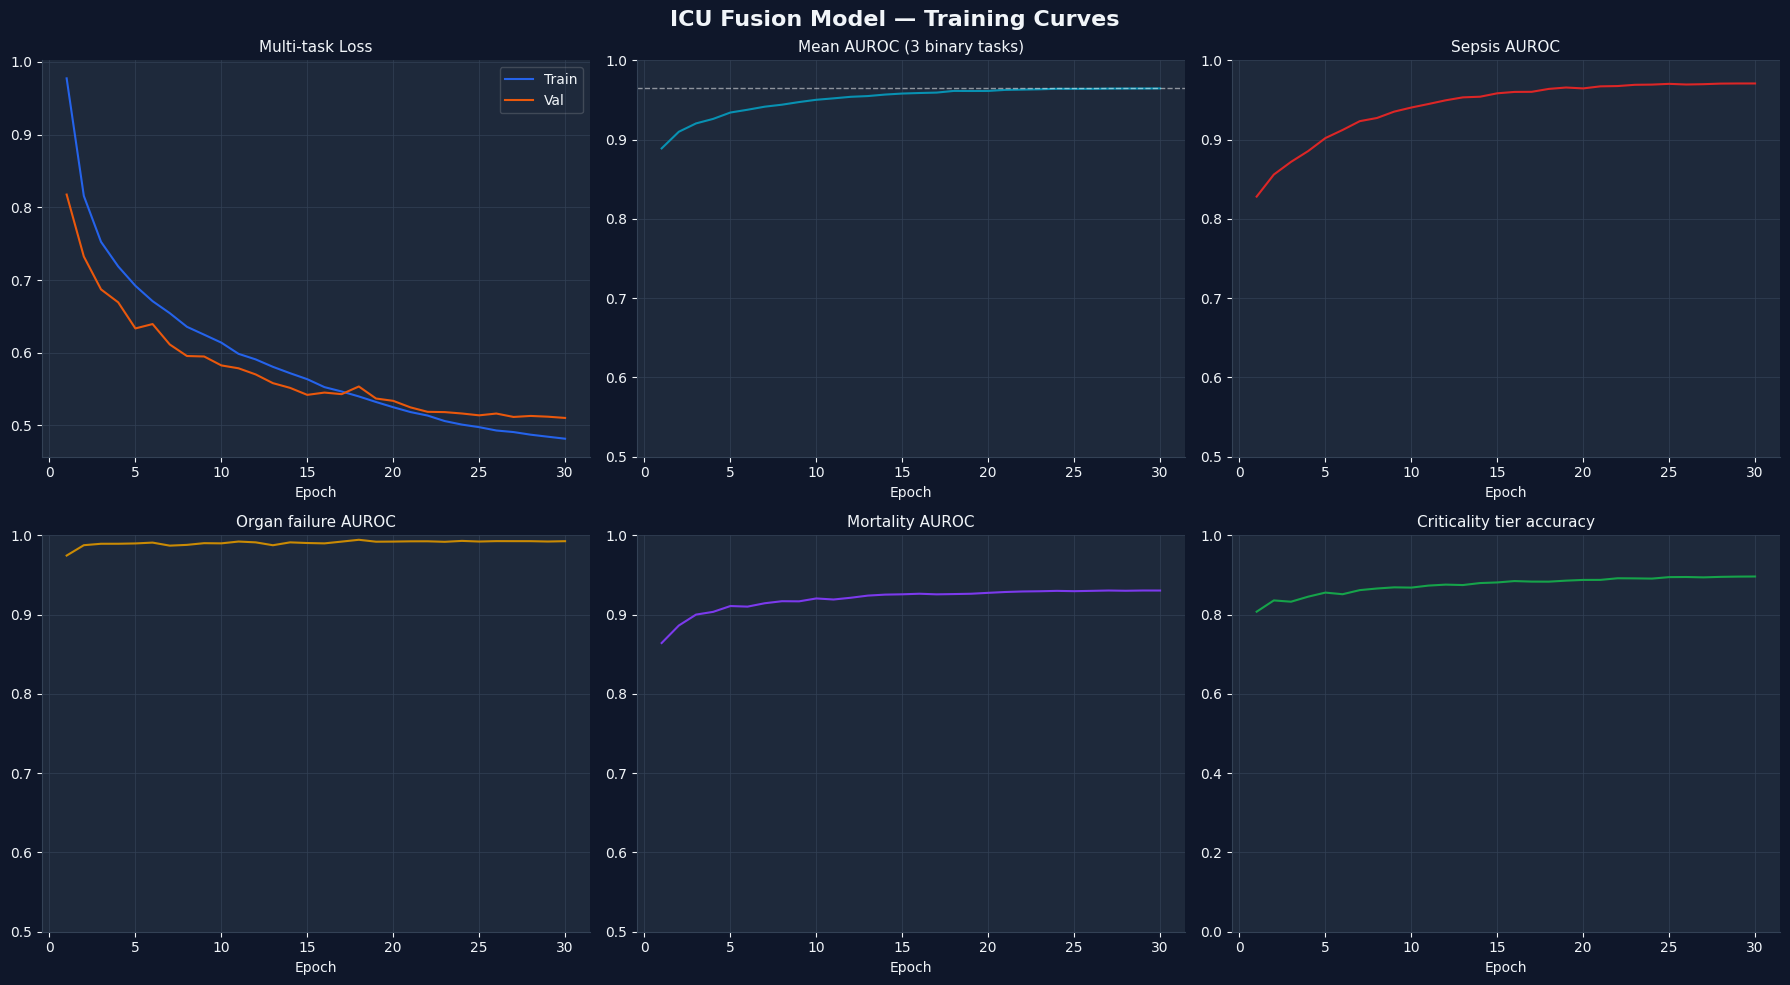

In [15]:
def sp(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=DARK_BG)
fig.suptitle('ICU Fusion Model — Training Curves', fontsize=16,
             fontweight='bold', color=TEXT)

epochs = history_df['epoch']

# Loss
ax = axes[0,0]
ax.plot(epochs, history_df['train_loss'], color=PAL['blue'],  label='Train')
ax.plot(epochs, history_df['val_loss'],   color=PAL['orange'],label='Val')
ax.set_title('Multi-task Loss'); ax.set_xlabel('Epoch')
ax.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax)

# Mean AUROC
ax = axes[0,1]
ax.plot(epochs, history_df['mean_auroc'], color=PAL['teal'])
ax.axhline(best_val_auroc, color='white', ls='--', lw=1, alpha=0.5)
ax.set_title('Mean AUROC (3 binary tasks)'); ax.set_xlabel('Epoch')
ax.set_ylim(0.5, 1.0); sp(ax)

# Per-task AUROCs
tasks = [('sepsis_auroc','Sepsis AUROC',PAL['red']),
         ('organ_failure_auroc','Organ failure AUROC',PAL['amber']),
         ('mortality_auroc','Mortality AUROC',PAL['purple'])]
for i, (col, title, color) in enumerate(tasks):
    ax = axes[0,2] if i == 0 else axes[1,i-1]
    ax.plot(epochs, history_df[col], color=color)
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.set_ylim(0.5, 1.0); sp(ax)

# Criticality accuracy
ax = axes[1,2]
ax.plot(epochs, history_df['criticality_acc'], color=PAL['green'])
ax.set_title('Criticality tier accuracy'); ax.set_xlabel('Epoch')
ax.set_ylim(0, 1.0); sp(ax)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'icu_fusion_training_curves.png',
            dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
log.info('Training curves saved.')

## Step 10 — Test Set Evaluation


TEST SET RESULTS
  sepsis               AUROC=0.9710  AUPRC=0.9978
  organ_failure        AUROC=0.9906  AUPRC=1.0000
  mortality            AUROC=0.9328  AUPRC=0.9300
  criticality          Accuracy=0.8927


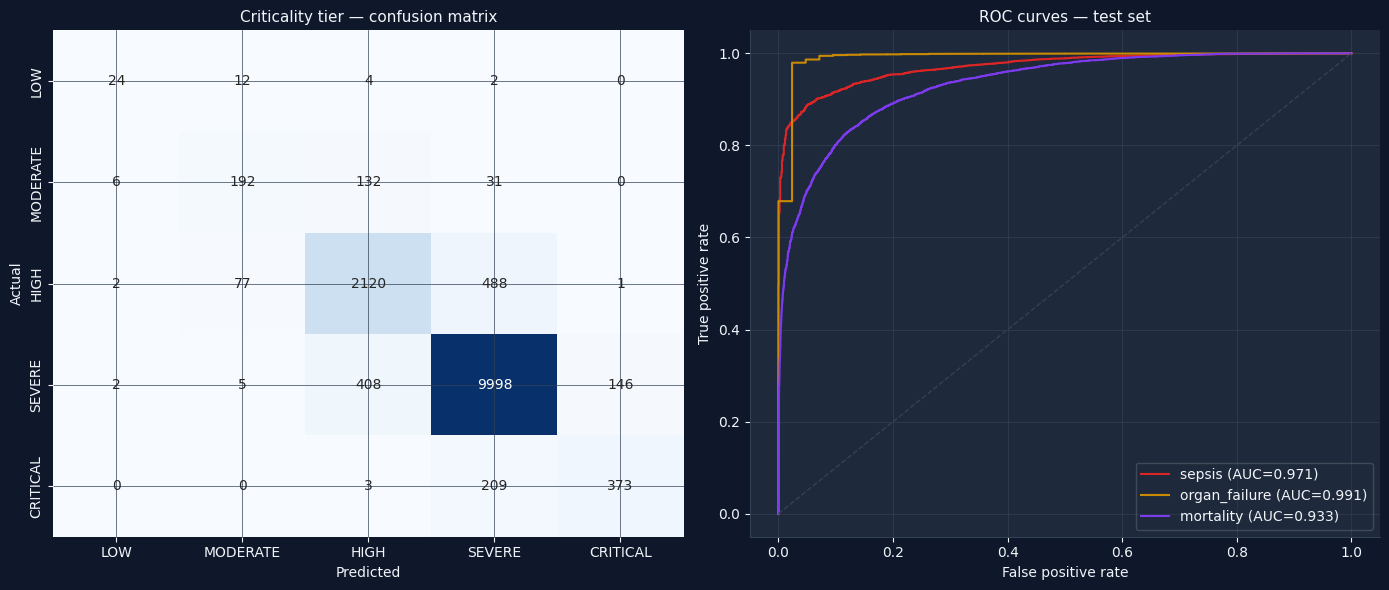

In [16]:
# Load best model
model.load_state_dict(torch.load(MODEL_DIR / 'icu_fusion_best.pt',
                                  map_location=DEVICE))
model.eval()

test_metrics, test_preds, test_labels = evaluate(test_loader, 'test')

print('\n' + '='*60)
print('TEST SET RESULTS')
print('='*60)
for task in ['sepsis','organ_failure','mortality']:
    print(f'  {task:<20} AUROC={test_metrics[f"{task}_auroc"]:.4f}  '
          f'AUPRC={test_metrics[f"{task}_auprc"]:.4f}')
print(f'  {"criticality":<20} Accuracy={test_metrics["criticality_acc"]:.4f}')
print('='*60)

# Confusion matrix for criticality
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=DARK_BG)

# Criticality confusion matrix
ax = axes[0]
cm = confusion_matrix(test_labels['criticality'], test_preds['criticality'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER,
            ax=ax, cbar=False)
ax.set_title('Criticality tier — confusion matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# ROC curves for binary tasks
from sklearn.metrics import roc_curve
ax = axes[1]
ax.set_facecolor(CARD_BG)
task_colors = {'sepsis':PAL['red'],'organ_failure':PAL['amber'],'mortality':PAL['purple']}
for task, color in task_colors.items():
    fpr, tpr, _ = roc_curve(test_labels[task], test_preds[task])
    auc = test_metrics[f'{task}_auroc']
    ax.plot(fpr, tpr, color=color, lw=1.5,
            label=f'{task} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'--', color=GRID, lw=1)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curves — test set')
ax.legend(framealpha=0.2, facecolor=CARD_BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'icu_fusion_test_results.png',
            dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## Step 11 — Generate Predictions for All Stays

In [17]:
# ── Run inference on full dataset (train+val+test)
full_ds     = ICUMultimodalDataset(master, TS_COLS, TEXT_COLS, CXR_FEAT_COLS, CXR_PROB_COLS)
full_loader = DataLoader(full_ds, batch_size=512, shuffle=False, num_workers=2)

all_rows = []
model.eval()

with torch.no_grad():
    for ts, text, cxr, mask, targets, stay_ids in tqdm(full_loader, desc='Full inference'):
        ts, text, cxr, mask = ts.to(DEVICE), text.to(DEVICE), cxr.to(DEVICE), mask.to(DEVICE)
        out = model(ts, text, cxr, mask)

        p_sepsis   = torch.sigmoid(out['sepsis']).cpu().numpy()
        p_organ    = torch.sigmoid(out['organ_failure']).cpu().numpy()
        p_mort     = torch.sigmoid(out['mortality']).cpu().numpy()
        crit_probs = torch.softmax(out['criticality'], dim=-1).cpu().numpy()
        crit_pred  = crit_probs.argmax(axis=-1)
        fused_repr = out['fused_repr'].cpu().numpy()

        for i, sid in enumerate(stay_ids.numpy()):
            row = {
                'stay_id':              int(sid),
                'pred_sepsis_prob':     float(p_sepsis[i]),
                'pred_organ_failure_prob': float(p_organ[i]),
                'pred_mortality_prob':  float(p_mort[i]),
                'pred_criticality':     int(crit_pred[i]),
                'pred_criticality_tier': TIER_ORDER[int(crit_pred[i])],
            }
            # Criticality probabilities per tier
            for j, tier in enumerate(TIER_ORDER):
                row[f'pred_crit_prob_{tier}'] = float(crit_probs[i, j])
            # Fused representation (for SHAP)
            for d in range(fused_repr.shape[1]):
                row[f'fusion_dim_{d}'] = float(fused_repr[i, d])
            all_rows.append(row)

predictions_df = pd.DataFrame(all_rows)

# Merge with split and ground truth
predictions_df = predictions_df.merge(
    master[['stay_id','split'] + TARGET_COLS], on='stay_id', how='left'
)

# Save
PRED_OUT = BASE / 'icu_fusion_predictions.parquet'
predictions_df.to_parquet(PRED_OUT, index=False, engine='pyarrow', compression='snappy')
log.info('Predictions saved: %s | %s', PRED_OUT, predictions_df.shape)

Full inference:   0%|          | 0/185 [00:00<?, ?it/s]

## Step 12 — SHAP Explainability

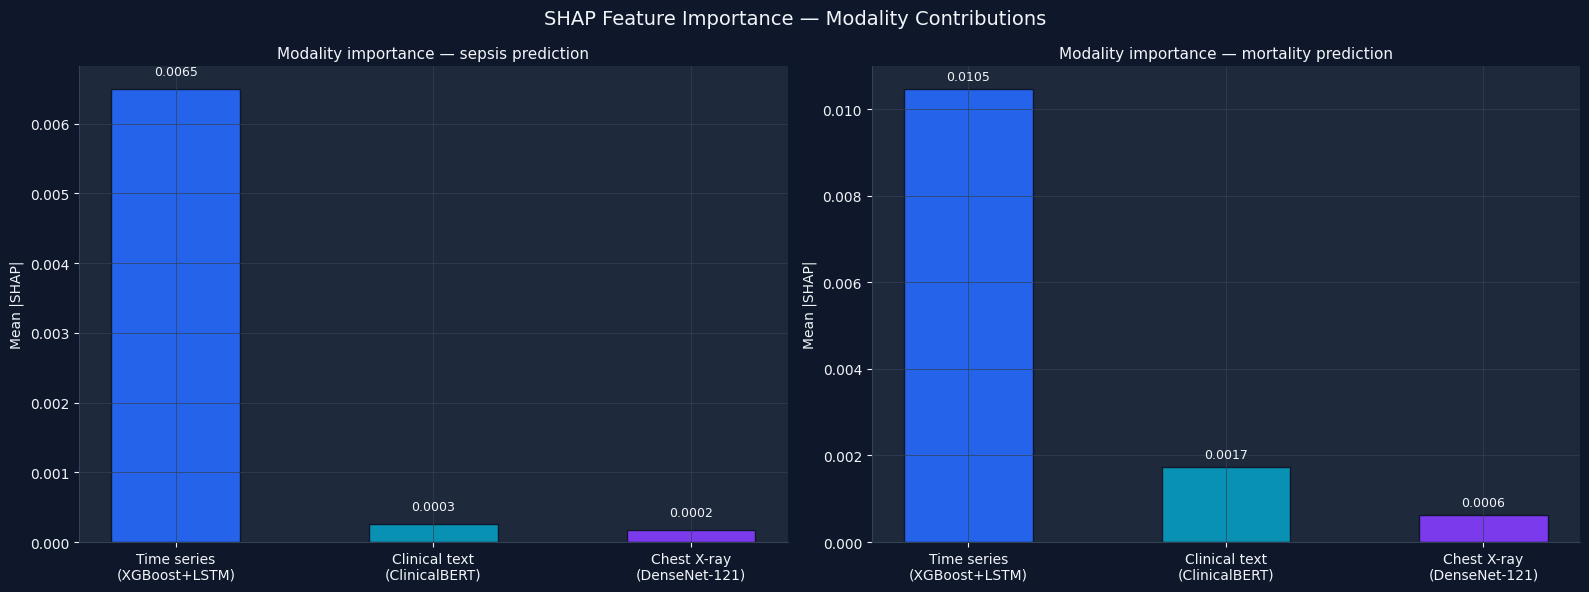

In [18]:
import shap

class SHAPWrapper(nn.Module):
    """Wrapper to expose a single scalar output for SHAP."""
    def __init__(self, fusion_model, task='sepsis'):
        super().__init__()
        self.model = fusion_model
        self.task  = task

    def forward(self, x):
        ts   = x[:, :TS_DIM]
        text = x[:, TS_DIM:TS_DIM+TEXT_DIM]
        cxr  = x[:, TS_DIM+TEXT_DIM:]
        mask = torch.ones(x.shape[0], 3, device=x.device)
        out  = self.model(ts, text, cxr, mask)
        return torch.sigmoid(out[self.task]).unsqueeze(-1)


# ── Background dataset (200 training samples)
bg_df   = train_df.sample(min(200, len(train_df)), random_state=42)
bg_ts   = torch.tensor(bg_df[TS_COLS].values.astype(np.float32))
bg_text = torch.tensor(bg_df[TEXT_COLS].values.astype(np.float32))
bg_cxr  = torch.tensor(bg_df[CXR_FEAT_COLS + CXR_PROB_COLS].values.astype(np.float32))
bg_x    = torch.cat([bg_ts, bg_text, bg_cxr], dim=-1).to(DEVICE)

# ── Test samples (100)
test_sample = test_df.sample(min(100, len(test_df)), random_state=42)
ts_x   = torch.tensor(test_sample[TS_COLS].values.astype(np.float32))
text_x = torch.tensor(test_sample[TEXT_COLS].values.astype(np.float32))
cxr_x  = torch.tensor(test_sample[CXR_FEAT_COLS + CXR_PROB_COLS].values.astype(np.float32))
test_x = torch.cat([ts_x, text_x, cxr_x], dim=-1).to(DEVICE)

shap_results = {}
for task in ['sepsis', 'mortality']:
    log.info('Computing SHAP (GradientExplainer) for task: %s', task)
    wrapper = SHAPWrapper(model, task=task).to(DEVICE)
    wrapper.eval()

    # ── GradientExplainer works with any PyTorch graph including attention
    explainer = shap.GradientExplainer(wrapper, bg_x)
    shap_vals = explainer.shap_values(test_x, nsamples=50)

    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 0]   # (N, features, 1) → (N, features)

    shap_results[task] = shap_vals
    log.info('SHAP %s: shape=%s', task, shap_vals.shape)


# ── Modality-level importance bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=DARK_BG)
fig.suptitle('SHAP Feature Importance — Modality Contributions',
             fontsize=14, color=TEXT)

for ax, task in zip(axes, ['sepsis', 'mortality']):
    sv       = np.abs(shap_results[task])
    ts_imp   = sv[:, :TS_DIM].mean()
    text_imp = sv[:, TS_DIM:TS_DIM+TEXT_DIM].mean()
    cxr_imp  = sv[:, TS_DIM+TEXT_DIM:].mean()

    modalities  = ['Time series\n(XGBoost+LSTM)',
                   'Clinical text\n(ClinicalBERT)',
                   'Chest X-ray\n(DenseNet-121)']
    importances = [ts_imp, text_imp, cxr_imp]
    colors      = [PAL['blue'], PAL['teal'], PAL['purple']]

    bars = ax.bar(modalities, importances, color=colors,
                  edgecolor=DARK_BG, width=0.5)
    for bar, val in zip(bars, importances):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.0002,
                f'{val:.4f}', ha='center', fontsize=9, color=TEXT)
    ax.set_facecolor(CARD_BG)
    ax.set_title(f'Modality importance — {task} prediction')
    ax.set_ylabel('Mean |SHAP|')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'icu_fusion_shap_modality.png',
            dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

# ── Save SHAP values
np.save(MODEL_DIR / 'shap_sepsis.npy',    shap_results['sepsis'])
np.save(MODEL_DIR / 'shap_mortality.npy', shap_results['mortality'])
log.info('SHAP values saved.')

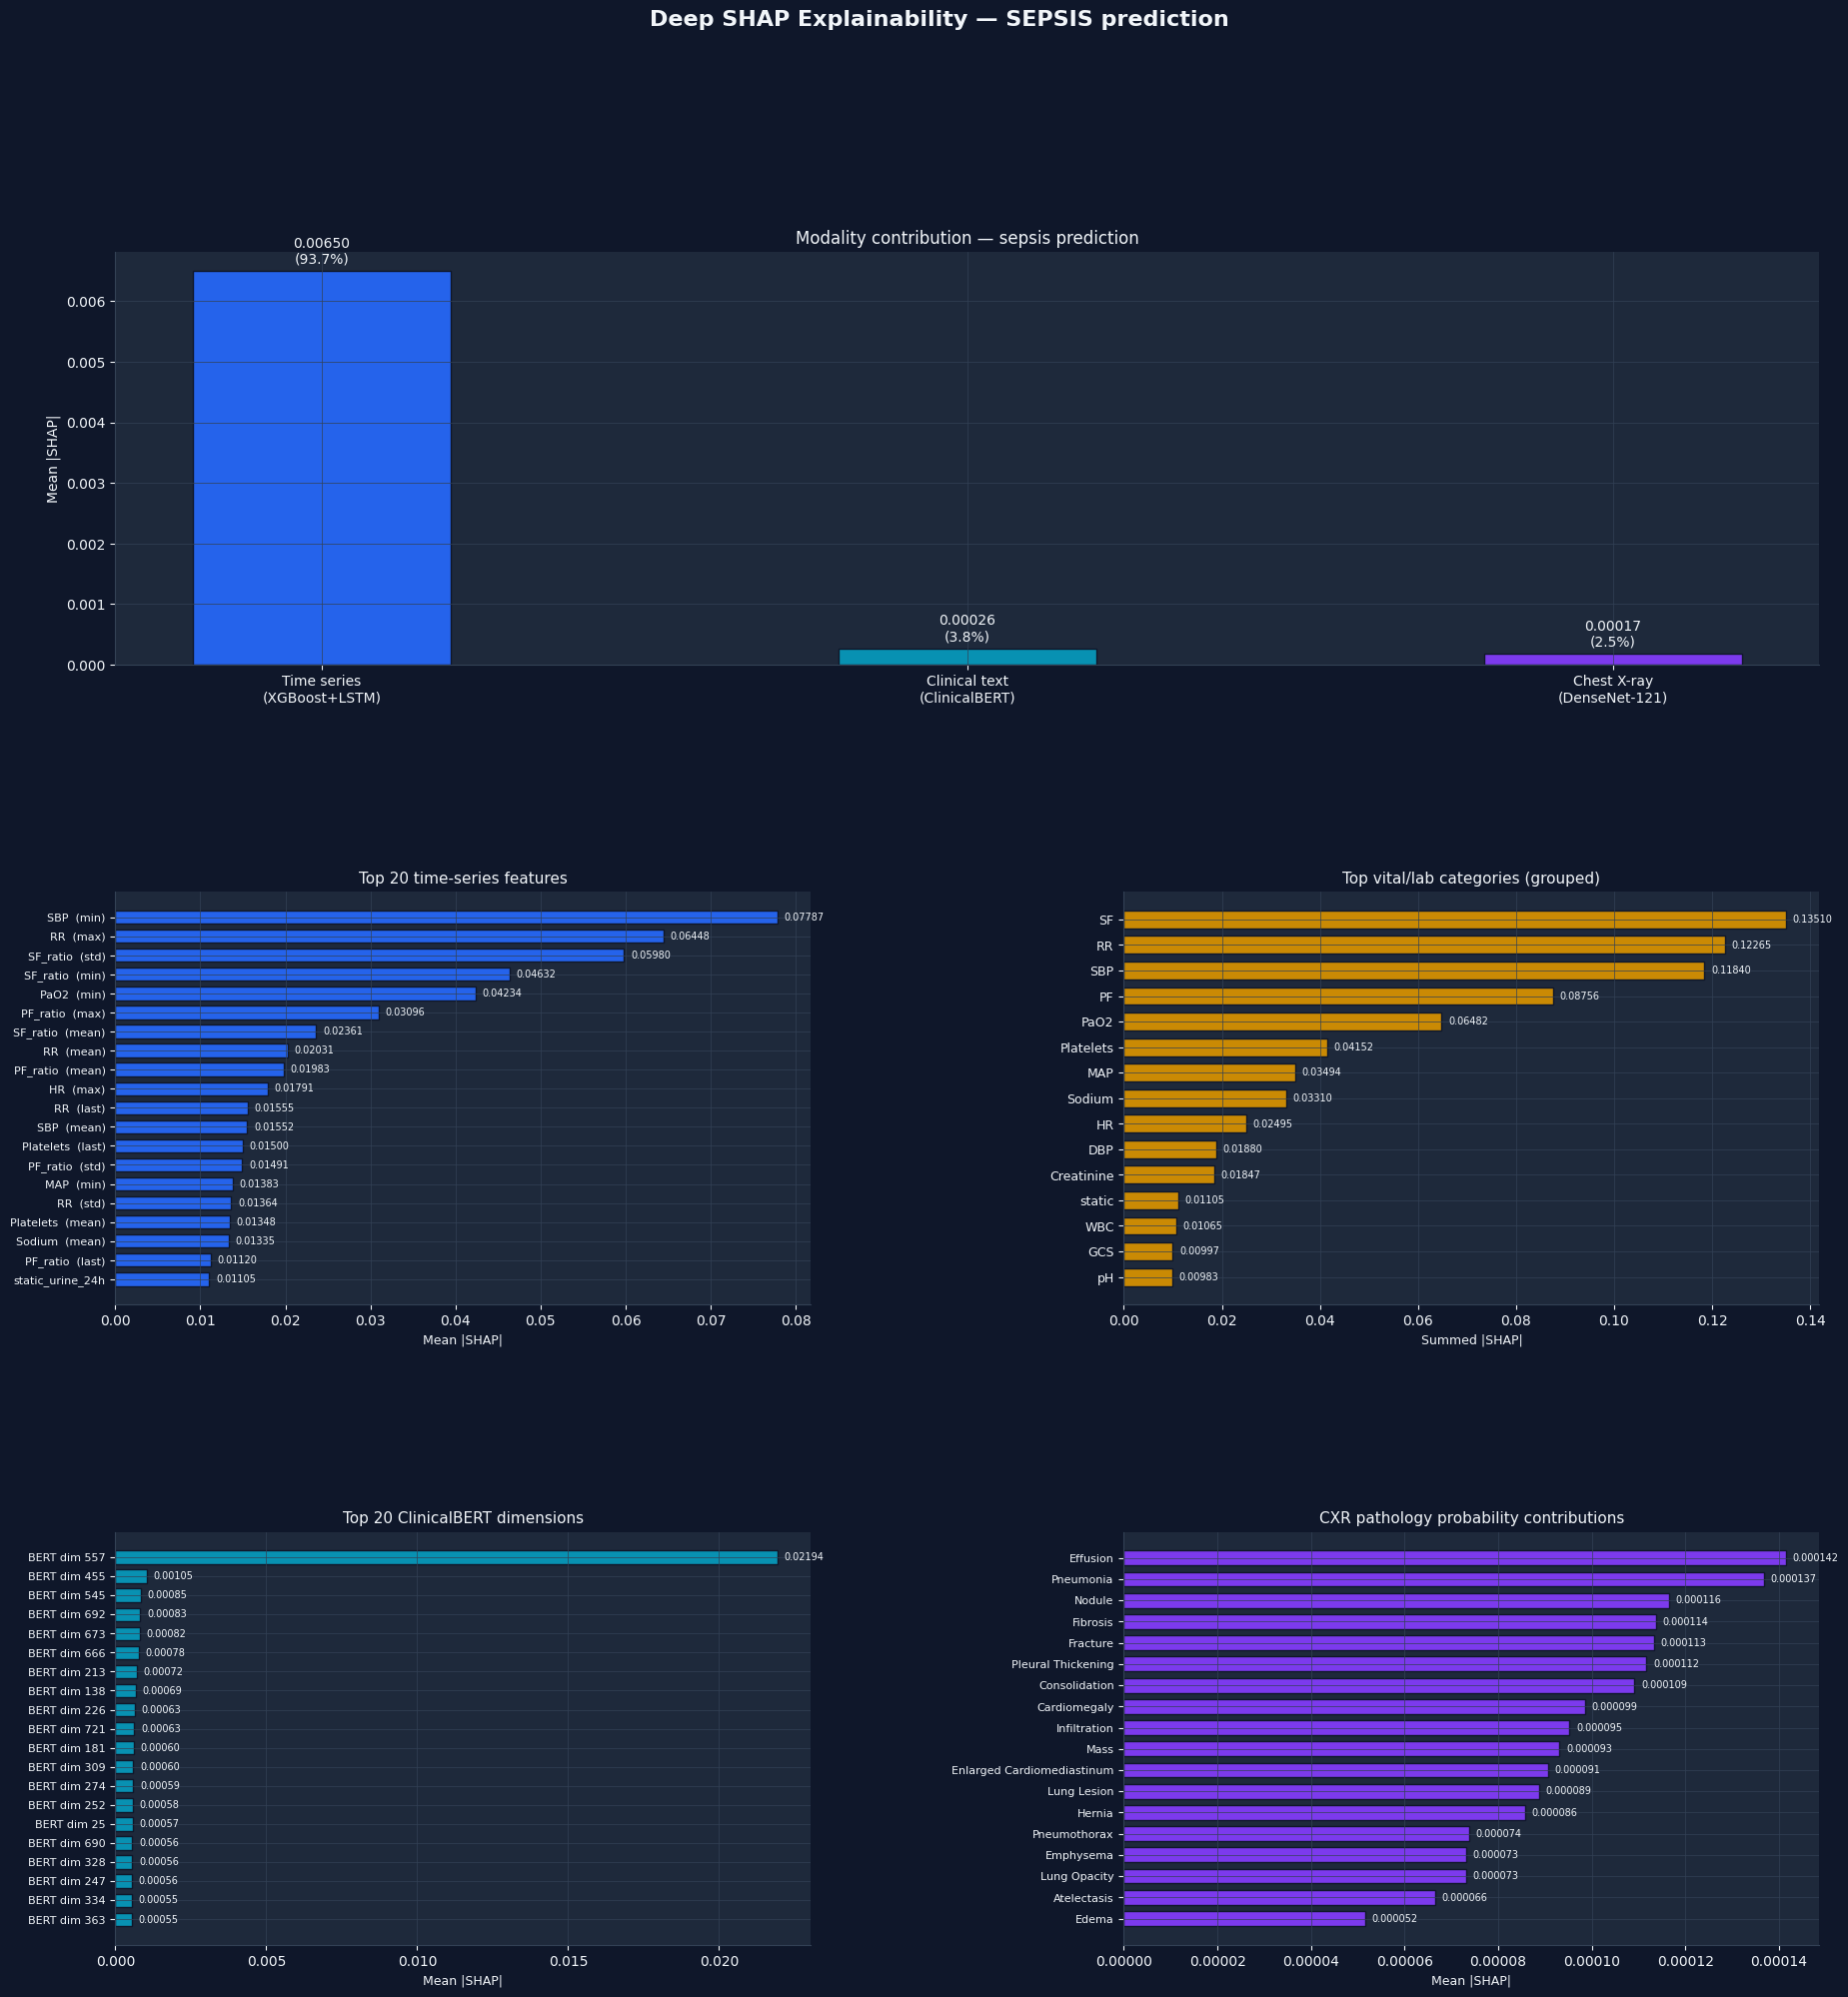

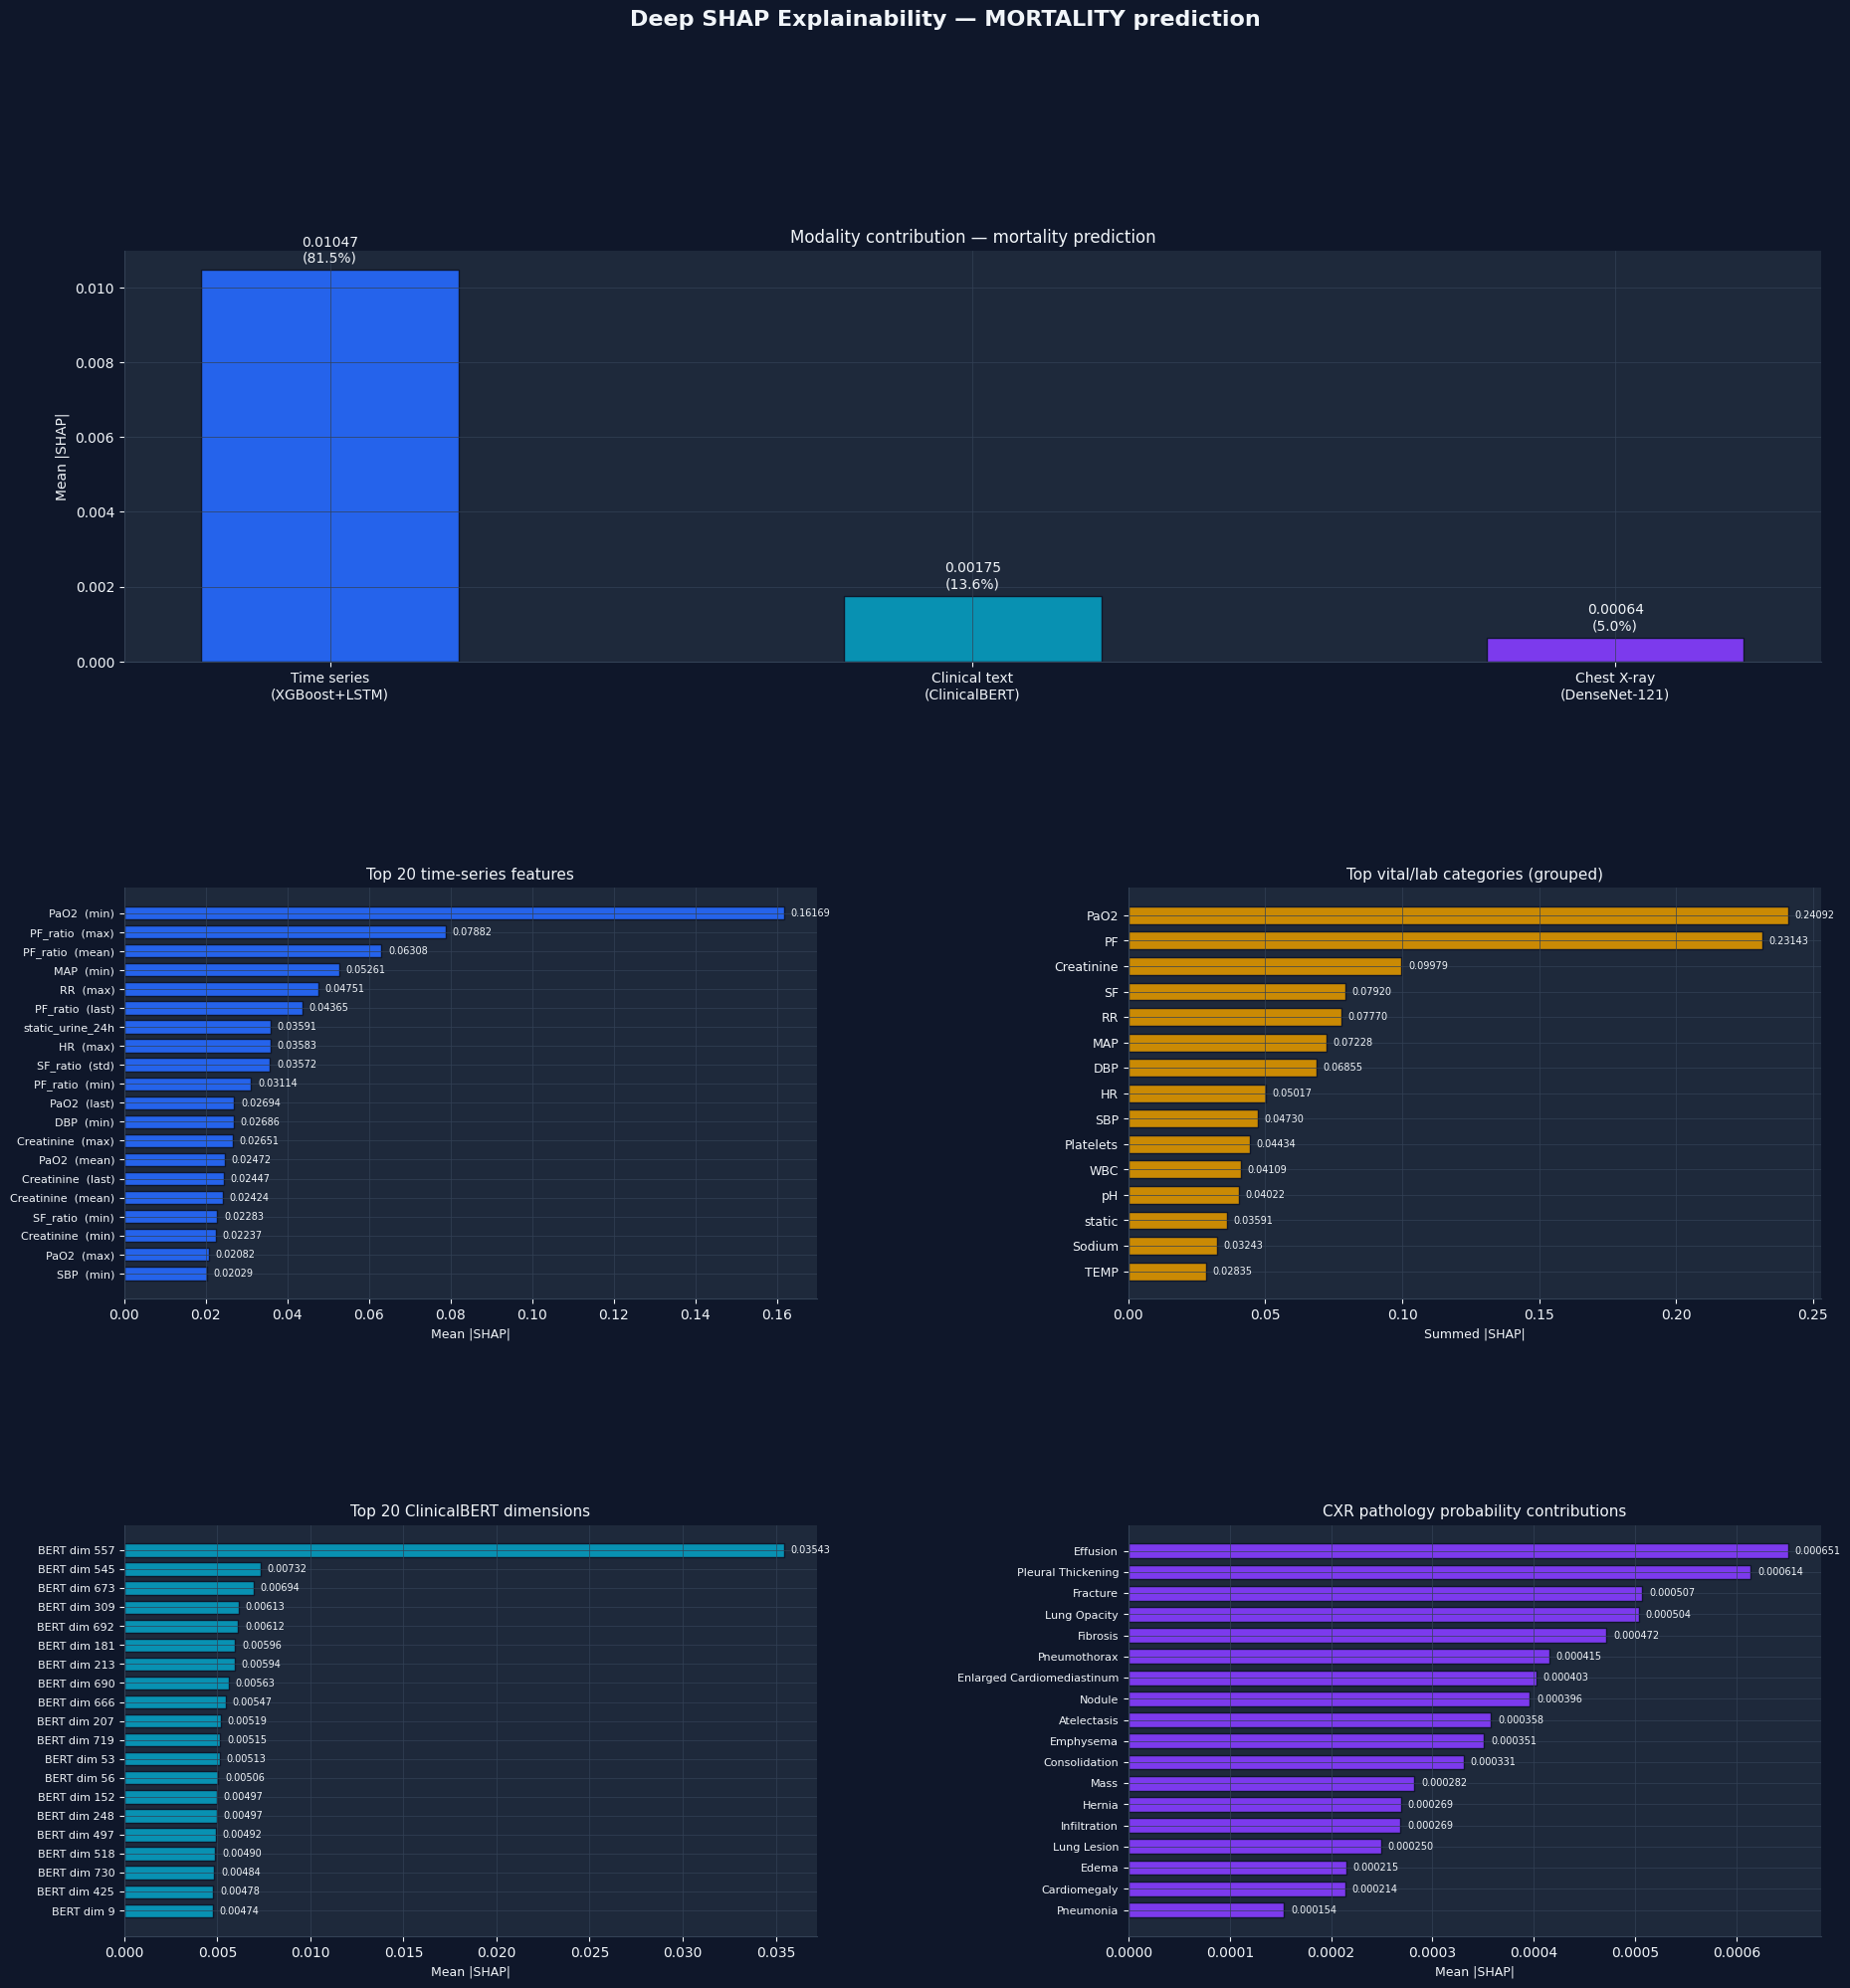

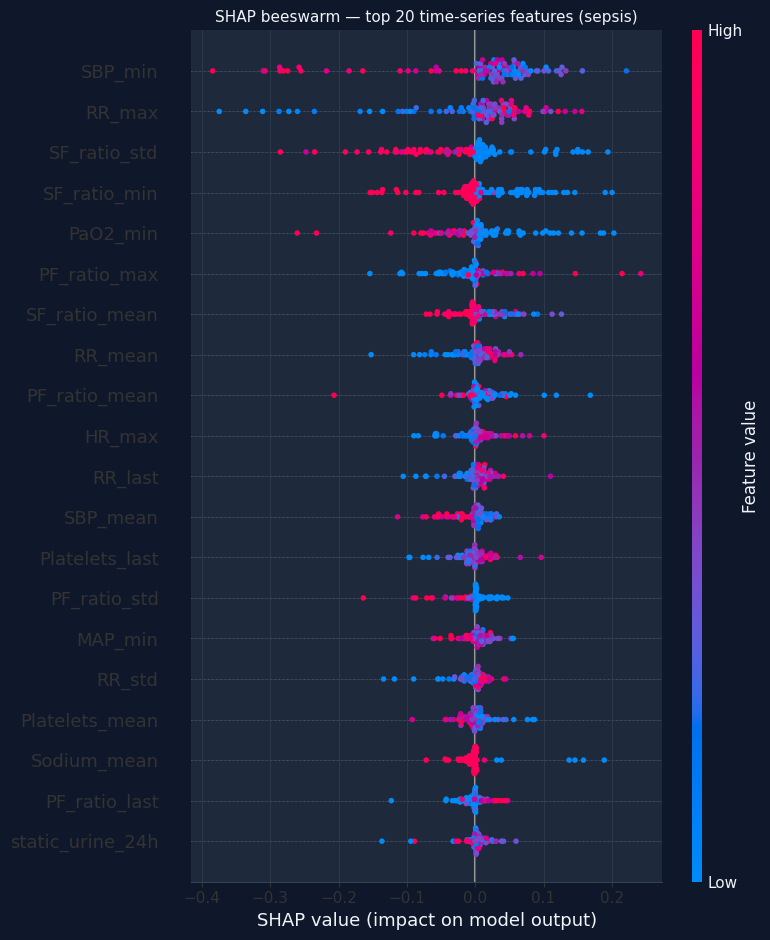

In [19]:
# ── Deep SHAP: Top features within each modality

import matplotlib.ticker as ticker

# ── 1. Top time-series features
def plot_top_features(shap_vals, feat_names, feat_start, feat_end,
                      title, top_n=20, color=PAL['blue'], ax=None):
    """Bar chart of top N features by mean |SHAP| within a modality slice."""
    sv_slice = np.abs(shap_vals[:, feat_start:feat_end])
    mean_imp  = sv_slice.mean(axis=0)
    top_idx   = np.argsort(mean_imp)[-top_n:][::-1]
    top_names = [feat_names[feat_start + i] for i in top_idx]
    top_vals  = mean_imp[top_idx]

    # Clean up feature names for display
    clean_names = []
    for n in top_names:
        n = n.replace('bert_dim_','BERT dim ')
        n = n.replace('cxr_feat_','CXR feat ')
        n = n.replace('cxr_prob_','CXR: ')
        n = n.replace('_mean','  (mean)')
        n = n.replace('_std','  (std)')
        n = n.replace('_min','  (min)')
        n = n.replace('_max','  (max)')
        n = n.replace('_last','  (last)')
        clean_names.append(n[:40])   # truncate long names

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8), facecolor=DARK_BG)

    bars = ax.barh(range(len(top_vals)), top_vals[::-1],
                   color=color, edgecolor=DARK_BG, height=0.7)
    ax.set_yticks(range(len(top_vals)))
    ax.set_yticklabels(clean_names[::-1], fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_facecolor(CARD_BG)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, val in zip(bars, top_vals[::-1]):
        ax.text(val + max(top_vals)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.5f}', va='center', fontsize=7, color=TEXT)
    return ax


ALL_FEAT_NAMES = TS_COLS + TEXT_COLS + (CXR_FEAT_COLS + CXR_PROB_COLS)
TS_END   = TS_DIM
TEXT_END = TS_DIM + TEXT_DIM
CXR_END  = TS_DIM + TEXT_DIM + CXR_INPUT_DIM


# ── Plot for each task
for task in ['sepsis', 'mortality']:
    sv = shap_results[task]

    fig = plt.figure(figsize=(22, 22), facecolor=DARK_BG)
    fig.suptitle(f'Deep SHAP Explainability — {task.upper()} prediction',
                 fontsize=16, fontweight='bold', color=TEXT, y=0.99)

    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.45)

    # ── Row 1: Modality overview (full width)
    ax_overview = fig.add_subplot(gs[0, :])
    ts_imp   = np.abs(sv[:, :TS_END]).mean()
    text_imp = np.abs(sv[:, TS_END:TEXT_END]).mean()
    cxr_imp  = np.abs(sv[:, TEXT_END:]).mean()
    total    = ts_imp + text_imp + cxr_imp + 1e-10

    modalities  = ['Time series\n(XGBoost+LSTM)',
                   'Clinical text\n(ClinicalBERT)',
                   'Chest X-ray\n(DenseNet-121)']
    importances = [ts_imp, text_imp, cxr_imp]
    pcts        = [v/total*100 for v in importances]
    colors_bar  = [PAL['blue'], PAL['teal'], PAL['purple']]

    bars = ax_overview.bar(modalities, importances,
                           color=colors_bar, edgecolor=DARK_BG, width=0.4)
    for bar, val, pct in zip(bars, importances, pcts):
        ax_overview.text(bar.get_x()+bar.get_width()/2,
                         val + max(importances)*0.02,
                         f'{val:.5f}\n({pct:.1f}%)',
                         ha='center', fontsize=10, color=TEXT)
    ax_overview.set_title(f'Modality contribution — {task} prediction', fontsize=12)
    ax_overview.set_ylabel('Mean |SHAP|')
    ax_overview.set_facecolor(CARD_BG)
    ax_overview.spines['top'].set_visible(False)
    ax_overview.spines['right'].set_visible(False)

    # ── Row 2 left: Top time-series features
    ax_ts = fig.add_subplot(gs[1, 0])
    plot_top_features(sv, ALL_FEAT_NAMES,
                      feat_start=0, feat_end=TS_END,
                      title='Top 20 time-series features',
                      top_n=20, color=PAL['blue'], ax=ax_ts)

    # ── Row 2 right: Time-series feature categories
    # Group TS features by vital sign / lab category
    ax_cat = fig.add_subplot(gs[1, 1])
    sv_ts   = np.abs(sv[:, :TS_END]).mean(axis=0)
    ts_feat_names = np.array(TS_COLS)

    # Auto-group by common suffixes
    groups = {}
    for fname, fval in zip(ts_feat_names, sv_ts):
        # Extract base vital/lab name (before _mean/_std etc)
        base = fname.split('_')[0] if '_' in fname else fname
        groups[base] = groups.get(base, 0) + fval

    top_groups = sorted(groups.items(), key=lambda x: x[1], reverse=True)[:15]
    g_names = [g[0] for g in top_groups]
    g_vals  = [g[1] for g in top_groups]

    bars2 = ax_cat.barh(range(len(g_vals)), g_vals[::-1],
                        color=PAL['amber'], edgecolor=DARK_BG, height=0.7)
    ax_cat.set_yticks(range(len(g_vals)))
    ax_cat.set_yticklabels(g_names[::-1], fontsize=9)
    ax_cat.set_title('Top vital/lab categories (grouped)', fontsize=11)
    ax_cat.set_xlabel('Summed |SHAP|', fontsize=9)
    ax_cat.set_facecolor(CARD_BG)
    ax_cat.spines['top'].set_visible(False)
    ax_cat.spines['right'].set_visible(False)
    for bar, val in zip(bars2, g_vals[::-1]):
        ax_cat.text(val + max(g_vals)*0.01,
                    bar.get_y()+bar.get_height()/2,
                    f'{val:.5f}', va='center', fontsize=7, color=TEXT)

    # ── Row 3 left: Top text (BERT) dimensions
    ax_text = fig.add_subplot(gs[2, 0])
    plot_top_features(sv, ALL_FEAT_NAMES,
                      feat_start=TS_END, feat_end=TEXT_END,
                      title='Top 20 ClinicalBERT dimensions',
                      top_n=20, color=PAL['teal'], ax=ax_text)

    # ── Row 3 right: CXR pathology probabilities
    ax_cxr = fig.add_subplot(gs[2, 1])
    # Only show prob cols (interpretable) not raw DenseNet features
    prob_start = TS_DIM + TEXT_DIM + len(CXR_FEAT_COLS)
    prob_end   = CXR_END
    sv_probs   = np.abs(sv[:, prob_start:prob_end]).mean(axis=0)
    prob_labels = [c.replace('cxr_prob_','').replace('_',' ')
                   for c in CXR_PROB_COLS]

    sorted_idx = np.argsort(sv_probs)[::-1]
    bars3 = ax_cxr.barh(range(len(prob_labels)),
                        sv_probs[sorted_idx[::-1]],
                        color=PAL['purple'], edgecolor=DARK_BG, height=0.7)
    ax_cxr.set_yticks(range(len(prob_labels)))
    ax_cxr.set_yticklabels(
        [prob_labels[i] for i in sorted_idx[::-1]], fontsize=8)
    ax_cxr.set_title('CXR pathology probability contributions', fontsize=11)
    ax_cxr.set_xlabel('Mean |SHAP|', fontsize=9)
    ax_cxr.set_facecolor(CARD_BG)
    ax_cxr.spines['top'].set_visible(False)
    ax_cxr.spines['right'].set_visible(False)
    for bar, val in zip(bars3, sv_probs[sorted_idx[::-1]]):
        ax_cxr.text(val + max(sv_probs)*0.01,
                    bar.get_y()+bar.get_height()/2,
                    f'{val:.6f}', va='center', fontsize=7, color=TEXT)

    plt.savefig(MODEL_DIR / f'icu_shap_deep_{task}.png',
                dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    log.info('Deep SHAP plot saved for task: %s', task)


# ── SHAP beeswarm / scatter for top TS features (sepsis)
log.info('Generating SHAP beeswarm for top time-series features...')
sv_ts_only  = shap_results['sepsis'][:, :TS_END]
ts_mean_imp = np.abs(sv_ts_only).mean(axis=0)
top20_idx   = np.argsort(ts_mean_imp)[-20:]
top20_names = [TS_COLS[i] for i in top20_idx]
top20_shap  = sv_ts_only[:, top20_idx]
top20_vals  = test_sample[top20_names].values

shap.summary_plot(
    top20_shap,
    top20_vals,
    feature_names=top20_names,
    plot_type='dot',
    max_display=20,
    show=False,
    color_bar=True,
)
plt.title('SHAP beeswarm — top 20 time-series features (sepsis)', color=TEXT)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'icu_shap_beeswarm_sepsis.png',
            dpi=150, bbox_inches='tight')
plt.show()
log.info('Beeswarm plot saved.')

In [20]:
import shap, torch, numpy as np
from pathlib import Path

MODEL_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')

# Load model + test data (reuse existing setup from fusion notebook)
# background = X_train_tensor[:100]
# test_data  = X_test_tensor[:100]

# SHAP for organ failure (index 1)

# Instantiate the SHAPWrapper for organ_failure task
organ_failure_wrapper = SHAPWrapper(model, task='organ_failure').to(DEVICE)
organ_failure_wrapper.eval()

explainer  = shap.GradientExplainer(
    organ_failure_wrapper,
    bg_x # Use bg_x from cell-12
)
shap_vals  = explainer.shap_values(test_x) # Use test_x from cell-12

# organ failure is index 1
shap_organ = shap_vals if isinstance(shap_vals, np.ndarray) else shap_vals[0] # The wrapper returns a single output, so the list will contain one array or direct array if batch_size=1
# If shap_vals is a numpy array and has a third dimension (for multiple outputs), slice it.
# In this case, the SHAPWrapper is configured for a single task, so shap_vals should be (N, features).
if shap_organ.ndim == 3: # Handle case where it might be (N, features, 1) from GradientExplainer
    shap_organ = shap_organ[:, :, 0]

np.save(MODEL_DIR / 'shap_organ_failure.npy', shap_organ)
print('✅ Saved shap_organ_failure.npy:', shap_organ.shape)

✅ Saved shap_organ_failure.npy: (100, 1929)


## Step 13 — Per-Patient Explanation Function

In [21]:
TIER_LABELS = {0:'LOW',1:'MODERATE',2:'HIGH',3:'SEVERE',4:'CRITICAL'}
TIER_ICONS  = {0:'🟢',1:'🟡',2:'🟠',3:'🔴',4:'🔴'}


def explain_patient_fusion(stay_id: int) -> dict:
    """
    Returns full model explanation for one ICU patient.
    Used by the dashboard Tab 3.
    """
    row = predictions_df[predictions_df['stay_id'] == stay_id]
    if len(row) == 0:
        return {'error': f'stay_id {stay_id} not found in predictions'}

    r = row.iloc[0]
    result = {
        'stay_id': stay_id,
        'predictions': {
            'sepsis_prob':         round(float(r['pred_sepsis_prob']), 4),
            'organ_failure_prob':  round(float(r['pred_organ_failure_prob']), 4),
            'mortality_prob':      round(float(r['pred_mortality_prob']), 4),
            'criticality_tier':    r['pred_criticality_tier'],
            'criticality_probs':   {
                t: round(float(r[f'pred_crit_prob_{t}']), 4) for t in TIER_ORDER
            },
        },
        'alerts': [],
        'modality_availability': {
            'time_series': True,
            'text':  bool(master.loc[master['stay_id']==stay_id,'text_available'].iloc[0]),
            'cxr':   bool(master.loc[master['stay_id']==stay_id,'cxr_available'].iloc[0]),
        }
    }

    # Alerts
    if result['predictions']['sepsis_prob'] > 0.5:
        result['alerts'].append('⚠️  HIGH sepsis risk — review lactate, cultures')
    if result['predictions']['organ_failure_prob'] > 0.5:
        result['alerts'].append('⚠️  Organ failure risk — check SOFA score')
    if result['predictions']['mortality_prob'] > 0.4:
        result['alerts'].append('⚠️  Elevated mortality risk — consider escalation')
    if result['predictions']['criticality_tier'] in ['SEVERE','CRITICAL']:
        result['alerts'].append('🚨  CRITICAL/SEVERE tier — immediate review recommended')

    return result


# Demo
demo_id = predictions_df[predictions_df['pred_criticality']>=3]['stay_id'].iloc[0]
exp     = explain_patient_fusion(demo_id)
print(f'\nPatient {exp["stay_id"]} — Fusion Model Explanation')
print('─' * 50)
preds = exp['predictions']
print(f'  Sepsis risk       : {preds["sepsis_prob"]*100:.1f}%')
print(f'  Organ failure     : {preds["organ_failure_prob"]*100:.1f}%')
print(f'  Mortality risk    : {preds["mortality_prob"]*100:.1f}%')
print(f'  Criticality tier  : {preds["criticality_tier"]}')
if exp['alerts']:
    print('\nAlerts:')
    for a in exp['alerts']: print(f'  {a}')


Patient 30000213 — Fusion Model Explanation
──────────────────────────────────────────────────
  Sepsis risk       : 51.9%
  Organ failure     : 99.6%
  Mortality risk    : 98.1%
  Criticality tier  : SEVERE

Alerts:
  ⚠️  HIGH sepsis risk — review lactate, cultures
  ⚠️  Organ failure risk — check SOFA score
  ⚠️  Elevated mortality risk — consider escalation
  🚨  CRITICAL/SEVERE tier — immediate review recommended


## Step 14 — Save Model + Metadata for Dashboard

In [22]:
# Save full model config for dashboard loading
fusion_meta = {
    'model_class':    'ICUFusionModel',
    'ts_dim':         TS_DIM,
    'text_dim':       TEXT_DIM,
    'cxr_dim':        CXR_INPUT_DIM,
    'proj_dim':       PROJ_DIM,
    'ts_cols':        TS_COLS,
    'text_cols':      TEXT_COLS,
    'cxr_feat_cols':  CXR_FEAT_COLS,
    'cxr_prob_cols':  CXR_PROB_COLS,
    'target_cols':    TARGET_COLS,
    'tier_order':     TIER_ORDER,
    'best_val_auroc': best_val_auroc,
    'test_metrics':   {k: float(v) for k, v in test_metrics.items()},
}
with open(MODEL_DIR / 'fusion_meta.json', 'w') as f:
    json.dump(fusion_meta, f, indent=2)

log.info('Fusion metadata saved.')

# Final summary
print('\n' + '='*60)
print('FUSION LAYER — OUTPUT SUMMARY')
print('='*60)
print(f'  Model weights   : {MODEL_DIR}/icu_fusion_best.pt')
print(f'  Predictions     : {PRED_OUT}')
print(f'  Fusion metadata : {MODEL_DIR}/fusion_meta.json')
print(f'  SHAP values     : {MODEL_DIR}/shap_sepsis.npy + shap_mortality.npy')
print(f'\n  Test AUROC — sepsis: {test_metrics["sepsis_auroc"]:.4f}')
print(f'  Test AUROC — organ : {test_metrics["organ_failure_auroc"]:.4f}')
print(f'  Test AUROC — mort  : {test_metrics["mortality_auroc"]:.4f}')
print(f'  Test acc  — crit   : {test_metrics["criticality_acc"]:.4f}')
print(f'\n  Total stays with predictions: {len(predictions_df):,}')
print('='*60)


FUSION LAYER — OUTPUT SUMMARY
  Model weights   : /content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models/icu_fusion_best.pt
  Predictions     : /content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet/icu_fusion_predictions.parquet
  Fusion metadata : /content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models/fusion_meta.json
  SHAP values     : /content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models/shap_sepsis.npy + shap_mortality.npy

  Test AUROC — sepsis: 0.9710
  Test AUROC — organ : 0.9906
  Test AUROC — mort  : 0.9328
  Test acc  — crit   : 0.8927

  Total stays with predictions: 94,362


In [23]:
# ── Run this before moving to dashboard
from pathlib import Path
import pandas as pd, json

BASE      = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')

checks = {
    'icu_static_features.parquet':      BASE,
    'icu_encoder_features.parquet':     BASE,
    'icu_text_embeddings.parquet':      BASE,
    'icu_cxr_embeddings.parquet':       BASE,
    'icu_risk_scores.parquet':          BASE,
    'icu_fusion_predictions.parquet':   BASE,
    'icu_fusion_best.pt':               MODEL_DIR,
    'fusion_meta.json':                 MODEL_DIR,
    'embedding_meta.json':              MODEL_DIR,
    'shap_sepsis.npy':                  MODEL_DIR,
    'shap_mortality.npy':               MODEL_DIR,
}

print('=== FILE INVENTORY ===')
all_ok = True
for fname, folder in checks.items():
    p = folder / fname
    exists = p.exists()
    size   = f'{p.stat().st_size/1e6:.1f} MB' if exists else '---'
    status = '✅' if exists else '❌'
    print(f'  {status}  {size:>8}  {fname}')
    if not exists: all_ok = False

print()
if all_ok:
    print('✅ All files present — ready to build dashboard')
    # Quick preview of predictions
    preds = pd.read_parquet(BASE / 'icu_fusion_predictions.parquet')
    print(f'\nPredictions shape : {preds.shape}')
    print(f'Stays predicted   : {preds["stay_id"].nunique():,}')
    print(f'Splits            : {preds["split"].value_counts().to_dict()}')
    pred_cols = ['pred_sepsis_prob','pred_organ_failure_prob',
                 'pred_mortality_prob','pred_criticality_tier']
    print(f'\nSample predictions:')
    print(preds[pred_cols].describe().round(3).to_string())
else:
    print('❌ Some files missing — check above before proceeding')

=== FILE INVENTORY ===
  ✅    4.0 MB  icu_static_features.parquet
  ✅   18.3 MB  icu_encoder_features.parquet
  ✅  328.1 MB  icu_text_embeddings.parquet
  ✅  207.5 MB  icu_cxr_embeddings.parquet
  ✅    2.9 MB  icu_risk_scores.parquet
  ✅  201.5 MB  icu_fusion_predictions.parquet
  ✅   12.7 MB  icu_fusion_best.pt
  ✅    0.0 MB  fusion_meta.json
  ✅    0.0 MB  embedding_meta.json
  ✅    1.5 MB  shap_sepsis.npy
  ✅    1.5 MB  shap_mortality.npy

✅ All files present — ready to build dashboard

Predictions shape : (94362, 272)
Stays predicted   : 94,362
Splits            : {'train': 65991, 'test': 14235, 'val': 14136}

Sample predictions:
       pred_sepsis_prob  pred_organ_failure_prob  pred_mortality_prob
count         94362.000                94362.000            94362.000
mean              0.827                    0.955                0.483
std               0.303                    0.138                0.391
min               0.001                    0.000                0.000
25%     